#Setup

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn import metrics
from sklearn.preprocessing import PolynomialFeatures
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import accuracy_score, confusion_matrix, mean_squared_error, r2_score

In [ ]:
#Load dataset from https://www.kaggle.com/datasets/lainguyn123/student-performance-factors
df = pd.read_csv("StudentPerformanceFactors.csv")

# Basic exploration
print(df.head())
print(df.info())

   Hours_Studied  Attendance Parental_Involvement Access_to_Resources  \
0             23          84                  Low                High   
1             19          64                  Low              Medium   
2             24          98               Medium              Medium   
3             29          89                  Low              Medium   
4             19          92               Medium              Medium   

  Extracurricular_Activities  Sleep_Hours  Previous_Scores Motivation_Level  \
0                         No            7               73              Low   
1                         No            8               59              Low   
2                        Yes            7               91           Medium   
3                        Yes            8               98           Medium   
4                        Yes            6               65           Medium   

  Internet_Access  Tutoring_Sessions Family_Income Teacher_Quality  \
0             Ye

#Data Preparation

In [ ]:
# Select relevant columns
data = df[['Hours_Studied', 'Exam_Score']]

# Drop missing values if any
data = data.dropna()


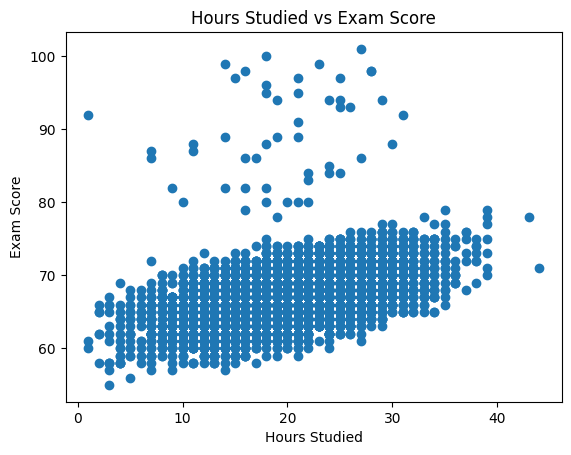

In [ ]:
# Split and Test Data for linear regression

x_train, x_test, y_train, y_test = train_test_split(data[['Hours_Studied']], data['Exam_Score'], random_state=42)

# Scatter plot of Hours studied vs Exam score
plt.scatter(data['Hours_Studied'], data['Exam_Score'])
plt.xlabel("Hours Studied")
plt.ylabel("Exam Score")
plt.title("Hours Studied vs Exam Score")
plt.show()


# Models

Model coefficient: 0.2860024210408706
Model intercept: 61.50824999224692
Linear Regression MSE: 10.4634
Linear Regression RMSE: 3.2347
Linear Regression R2 Score: 0.2318


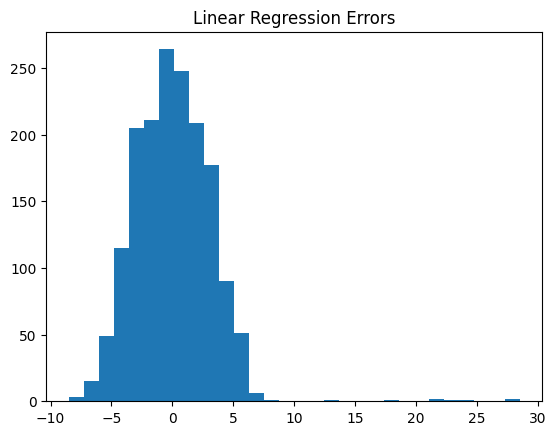

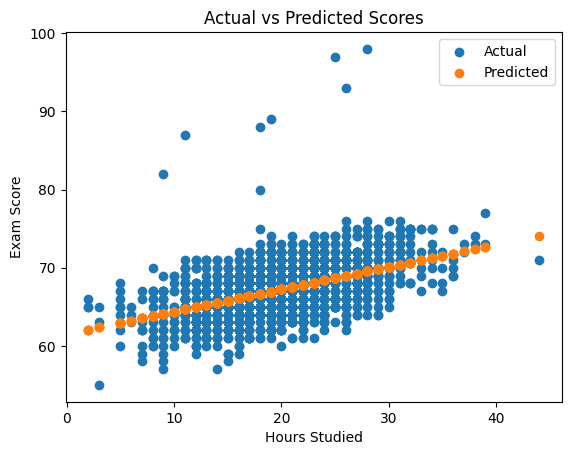

In [ ]:
# Linear Regression

lin_reg = LinearRegression().fit(x_train, y_train)
y_pred = lin_reg.predict(x_test)

# Evaluation metrics
mse_lin = mean_squared_error(y_test, y_pred)
rmse_lin = np.sqrt(mse_lin)
r2_lin = r2_score(y_test, y_pred)

print("Model coefficient:", lin_reg.coef_[0])
print("Model intercept:", lin_reg.intercept_)

print("Linear Regression MSE:", round(mse_lin, 4))
print("Linear Regression RMSE:", round(rmse_lin, 4))
print("Linear Regression R2 Score:", round(r2_lin, 4))

# Error Distribution
plt.hist(y_test - y_pred, bins=30)
plt.title("Linear Regression Errors")
plt.show()

# Actual vs Predicted plot
plt.scatter(x_test, y_test, label="Actual")
plt.scatter(x_test, y_pred, label="Predicted")
plt.xlabel("Hours Studied")
plt.ylabel("Exam Score")
plt.title("Actual vs Predicted Scores")
plt.legend()
plt.show()


Polynomial MSE: 10.4505
Polynomial RMSE: 3.2327
Polynomial R2 Score: 0.2327


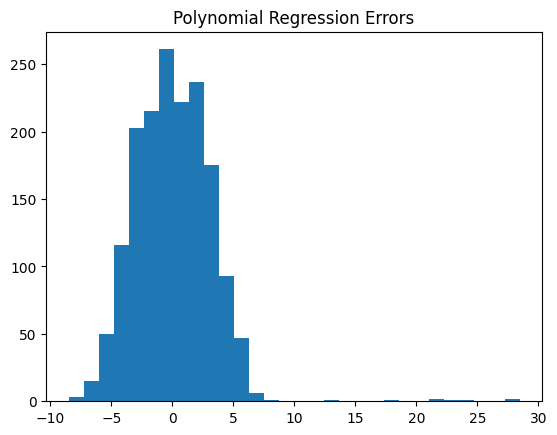

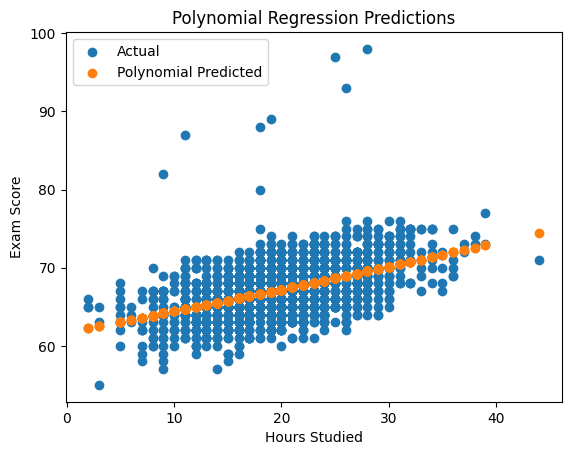

In [ ]:
# Polynomial Regression
poly = PolynomialFeatures(degree=2)

x_train_poly = poly.fit_transform(x_train)
x_test_poly = poly.transform(x_test)

poly_reg = LinearRegression().fit(x_train_poly, y_train)
y_pred_poly = poly_reg.predict(x_test_poly)

# Evaluation metrics
mse_poly = mean_squared_error(y_test, y_pred_poly)
rmse_poly = np.sqrt(mse_poly)
r2_poly = r2_score(y_test, y_pred_poly)

print("Polynomial MSE:", round(mse_poly, 4))
print("Polynomial RMSE:", round(rmse_poly, 4))
print("Polynomial R2 Score:", round(r2_poly, 4))

# Error distribution
plt.hist(y_test - y_pred_poly, bins=30)
plt.title("Polynomial Regression Errors")
plt.show()

# Actual vs Predicted
plt.scatter(x_test, y_test, label="Actual")
plt.scatter(x_test, y_pred_poly, label="Polynomial Predicted")
plt.xlabel("Hours Studied")
plt.ylabel("Exam Score")
plt.title("Polynomial Regression Predictions")
plt.legend()
plt.show()


In [ ]:
# Compare the two models
print("Linear vs Polynomial Comparison")
print("Linear Regression R2:", round(r2_lin, 4))
print("Polynomial Regression R2:", round(r2_poly, 4))

if r2_poly > r2_lin:
    print("Polynomial regression performs better.")
else:
    print("Linear regression performs better.")


Linear vs Polynomial Comparison
Linear Regression R2: 0.2318
Polynomial Regression R2: 0.2327
Polynomial regression performs better.


# Addition Features Comparison


Multi-feature Regression Results
Features used: ['Hours_Studied', 'Sleep_Hours', 'Attendance', 'Previous_Scores', 'Tutoring_Sessions', 'Physical_Activity']
Multi-feature MSE: 4.7568
Multi-feature RMSE: 2.181
Multi-feature R2 Score: 0.6508


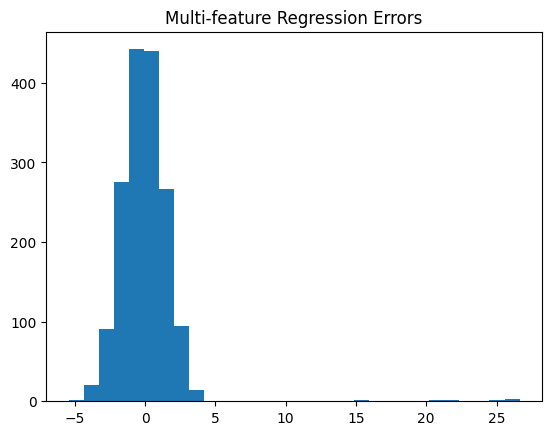

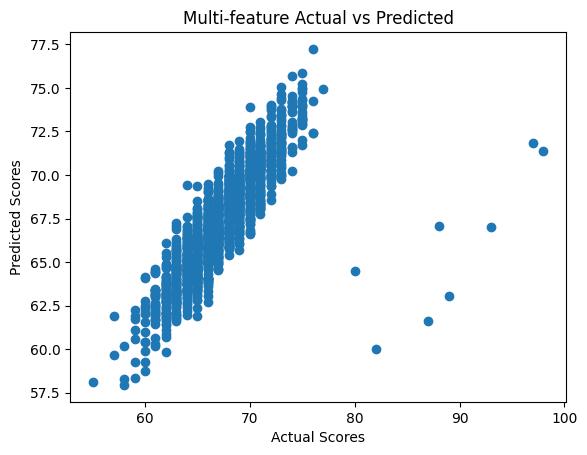

In [ ]:
# Additional features model
features = [
    'Hours_Studied',
    'Sleep_Hours',
    'Attendance',
    'Previous_Scores',
    'Tutoring_Sessions',
    'Physical_Activity'
]

data_multi = df[features + ['Exam_Score']].dropna()

x_train_m, x_test_m, y_train_m, y_test_m = train_test_split(
    data_multi[features],
    data_multi['Exam_Score'],
    random_state=42
)

multi_reg = LinearRegression().fit(x_train_m, y_train_m)
y_pred_multi = multi_reg.predict(x_test_m)

# Evaluation
mse_multi = mean_squared_error(y_test_m, y_pred_multi)
rmse_multi = np.sqrt(mse_multi)
r2_multi = r2_score(y_test_m, y_pred_multi)

print("\nMulti-feature Regression Results")
print("Features used:", features)
print("Multi-feature MSE:", round(mse_multi, 4))
print("Multi-feature RMSE:", round(rmse_multi, 4))
print("Multi-feature R2 Score:", round(r2_multi, 4))

# Error distribution
plt.hist(y_test_m - y_pred_multi, bins=30)
plt.title("Multi-feature Regression Errors")
plt.show()

# Actual vs Predicted
plt.scatter(y_test_m, y_pred_multi)
plt.xlabel("Actual Scores")
plt.ylabel("Predicted Scores")
plt.title("Multi-feature Actual vs Predicted")
plt.show()


In [ ]:
# Model using lifestyle/behavior-related factors
behavior_features = [
    'Hours_Studied',
    'Sleep_Hours',
    'Attendance',
    'Motivation_Level'
]

data_behavior = df[behavior_features + ['Exam_Score']].dropna()

# Convert categorical columns to numeric using one-hot encoding
data_behavior = pd.get_dummies(data_behavior, drop_first=True)

x_train_b, x_test_b, y_train_b, y_test_b = train_test_split(
    data_behavior.drop('Exam_Score', axis=1),
    data_behavior['Exam_Score'],
    test_size=0.2,
    random_state=42
)

behavior_reg = LinearRegression().fit(x_train_b, y_train_b)
y_pred_behavior = behavior_reg.predict(x_test_b)

mse_behavior = mean_squared_error(y_test_b, y_pred_behavior)
rmse_behavior = np.sqrt(mse_behavior)
r2_behavior = r2_score(y_test_b, y_pred_behavior)

print("\nBehavior Factors Model Results")
print("R2 Score:", round(r2_behavior, 4))




Behavior Factors Model Results
R2 Score: 0.599


In [ ]:
# Model using academic-related factors
academic_features = [
    'Previous_Scores',
    'Tutoring_Sessions',
    'Parental_Education_Level'
]

data_academic = df[academic_features + ['Exam_Score']].dropna()

# Convert categorical variables to numeric
data_academic = pd.get_dummies(data_academic, drop_first=True)

x_train_a, x_test_a, y_train_a, y_test_a = train_test_split(
    data_academic.drop('Exam_Score', axis=1),
    data_academic['Exam_Score'],
    test_size=0.2,
    random_state=42
)

academic_reg = LinearRegression().fit(x_train_a, y_train_a)
y_pred_academic = academic_reg.predict(x_test_a)

mse_academic = mean_squared_error(y_test_a, y_pred_academic)
rmse_academic = np.sqrt(mse_academic)
r2_academic = r2_score(y_test_a, y_pred_academic)

print("\nAcademic Factors Model Results")
print("R2 Score:", round(r2_academic, 4))



Academic Factors Model Results
R2 Score: 0.0784


In [ ]:
# Compare performance of all models
# Helps determine which approach predicts exam scores best
print("MODEL COMPARISONS")
print("Linear Regression R2:", round(r2_lin, 4))
print("Polynomial Regression R2:", round(r2_poly, 4))
print("Multi-feature Regression R2:", round(r2_multi, 4))
print("Behavior Model R2:", round(r2_behavior, 4))
print("Academic Model R2:", round(r2_academic, 4))

# Higher R2 = better model


MODEL COMPARISONS
Linear Regression R2: 0.2318
Polynomial Regression R2: 0.2327
Multi-feature Regression R2: 0.6508
Behavior Model R2: 0.599
Academic Model R2: 0.0784
